# Сравнение внутренних расхождений на агрегаторах

Этот ноутбук нужен для контекста: сначала смотрим, как расходятся оценки критиков и пользователей на других площадках. Это помогает не спутать обычные расхождения мнений с возможным завышением рейтингов у Fandango.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
sns.set_theme(style='white', palette='Set2')


,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,60.849315,63.876712,58.808219,6.519178,6.736986,185.705479,42846.205479
std,30.168799,20.024430,19.517389,1.510712,0.958736,316.606515,67406.509171
min,5.000000,20.000000,13.000000,2.400000,4.000000,4.000000,243.000000
25%,31.250000,50.000000,43.500000,5.700000,6.300000,33.250000,5627.000000
50%,63.500000,66.500000,59.000000,6.850000,6.900000,72.500000,19103.000000
75%,89.000000,81.000000,75.000000,7.500000,7.400000,168.500000,45185.750000
max,100.000000,94.000000,94.000000,9.600000,8.600000,2375.000000,334164.000000


## Rotten Tomatoes: критики против пользователей

Сравниваем два распределения на одной шкале от 0 до 100. Это базовая проверка, чтобы увидеть, насколько оценки аудитории обычно отличаются от оценок критиков.


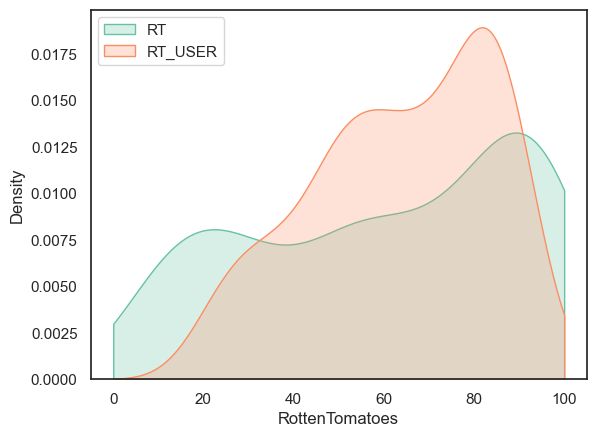

In [10]:
df = pd.read_csv('../data/all_sites_scores.csv')
sns.kdeplot(data=df, x='RottenTomatoes', clip=(0, 100), fill=True, label='RT')
sns.kdeplot(data=df, x='RottenTomatoes_User', clip=(0, 100), fill=True, label='RT_USER')
plt.legend()


## Направление расхождения на Rotten Tomatoes

Здесь разница считается как `критики - пользователи`. Положительное значение означает, что критики оценили фильм выше пользователей, отрицательное, наоборот, что аудитория была добрее.


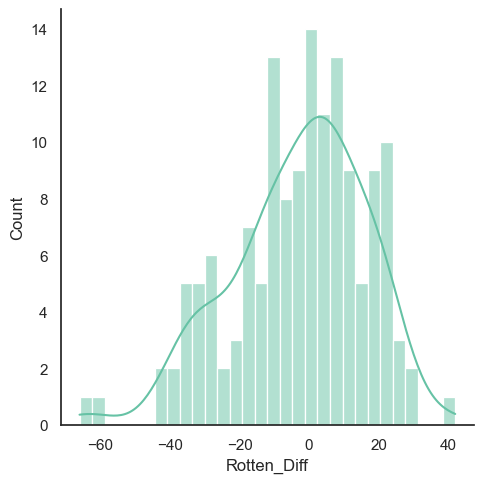

In [25]:
df = pd.read_csv('../data/all_sites_scores.csv')
df['Rotten_Diff'] = df['RottenTomatoes'] - df['RottenTomatoes_User']
sns.displot(data=df, x='Rotten_Diff', kde=True, bins=30)


## Сила расхождения на Rotten Tomatoes

Абсолютная разница показывает не направление, а величину спора между критиками и пользователями. Это отдельный ориентир: большие расхождения на сторонних сайтах ещё не означают манипуляцию, а лишь показывают, что мнения групп могут сильно отличаться.


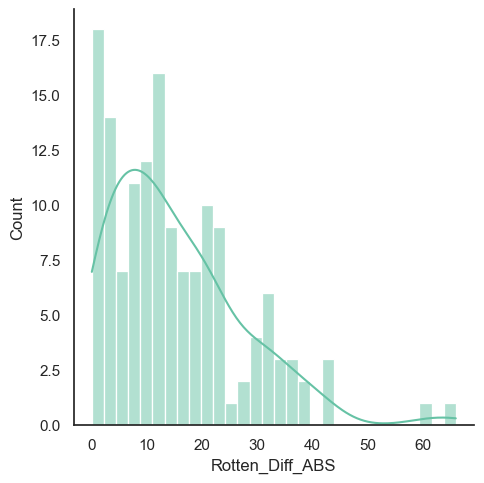

In [24]:
df = pd.read_csv('../data/all_sites_scores.csv')
df['Rotten_Diff_ABS'] = (df['RottenTomatoes'] - df['RottenTomatoes_User']).abs()
sns.displot(data=df, x='Rotten_Diff_ABS', kde=True, bins=30)


## Metacritic: критики против пользователей

Приводим пользовательские оценки Metacritic к шкале 0..100, чтобы графики можно было корректно сопоставить. Так видно, как выглядит обычный разрыв между критиками и пользователями на ещё одной крупной площадке.


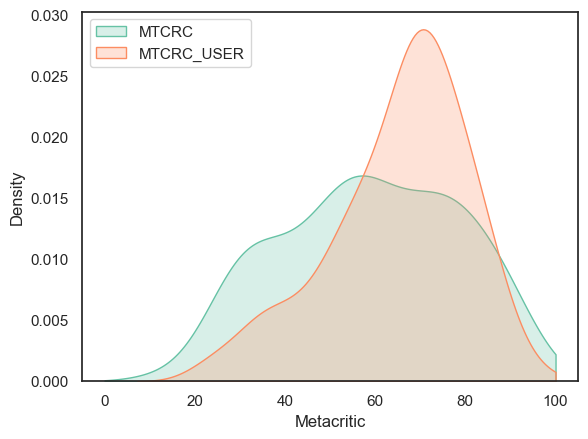

In [32]:
df = pd.read_csv('../data/all_sites_scores.csv')
df['Metacritic_User'] = (df['Metacritic_User'] * 10).astype(int)
sns.kdeplot(data=df, x='Metacritic', clip=(0, 100), fill=True, label='MTCRC')
sns.kdeplot(data=df, x='Metacritic_User', clip=(0, 100), fill=True, label='MTCRC_USER')
plt.legend()


## Промежуточный вывод

Другие сайты тоже показывают заметные расхождения между критиками и пользователями. Но эти расхождения сами по себе ещё не объясняют, почему у Fandango итоговые оценки оказываются настолько высокими по сравнению с конкурентами.
